### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings 

warnings.filterwarnings("ignore")

### Load Dataset

In [2]:
crop = pd.read_csv("../Data Set/Crop_recommendation.csv")

### Data Cleaning

In [3]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [4]:
crop.duplicated().value_counts()

False    2200
Name: count, dtype: int64

In [13]:
crop.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [14]:
crop['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [12]:
print(crop[crop['temperature']>500])
print(crop[crop['ph']<0])
print(crop[crop['K']<0])
print(crop[crop['P']<0])
print(crop[crop['N']<0])
print(crop[crop['humidity']<0])

Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []
Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []
Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []
Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []
Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []
Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []


### EDA

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

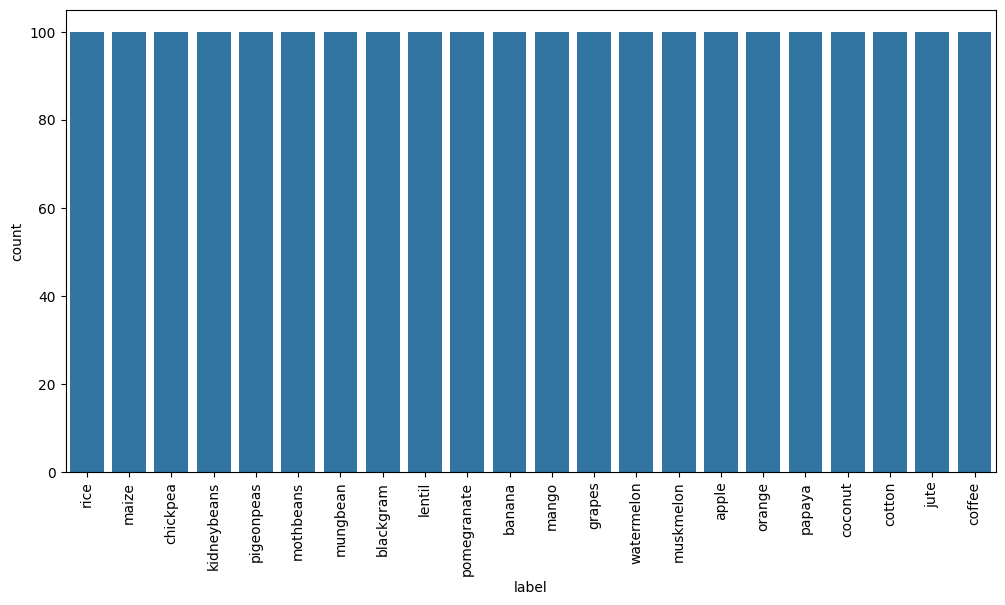

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(x='label',data=crop)
plt.xticks(rotation=90)
plt.show()

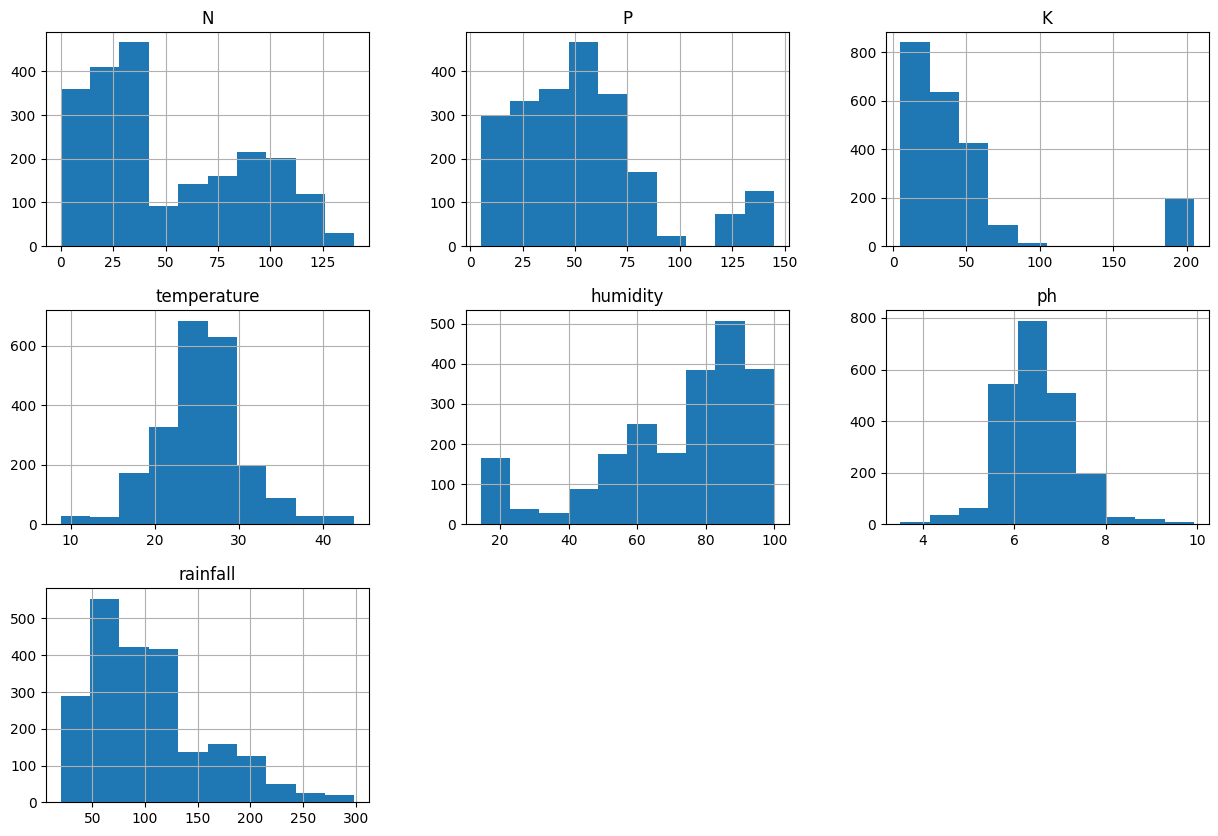

In [23]:
crop.hist(figsize=(15,10))
plt.show()

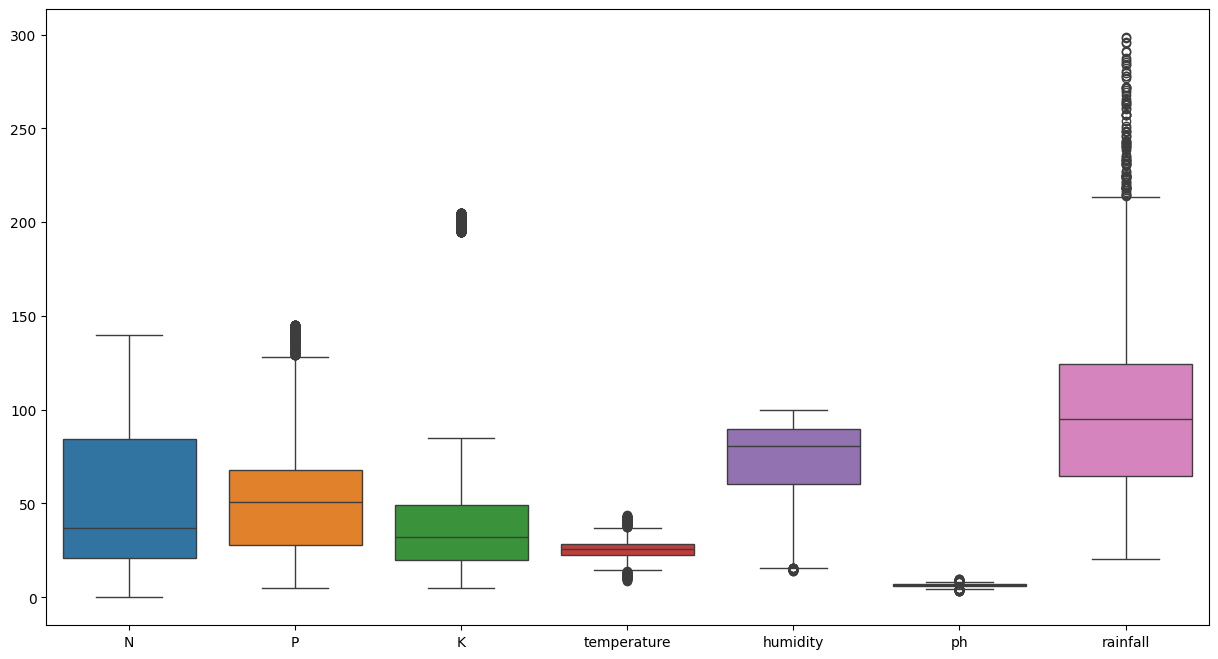

In [27]:
plt.figure(figsize=(15,8))
sns.boxplot(data=crop.drop("label",axis=1))
plt.show()

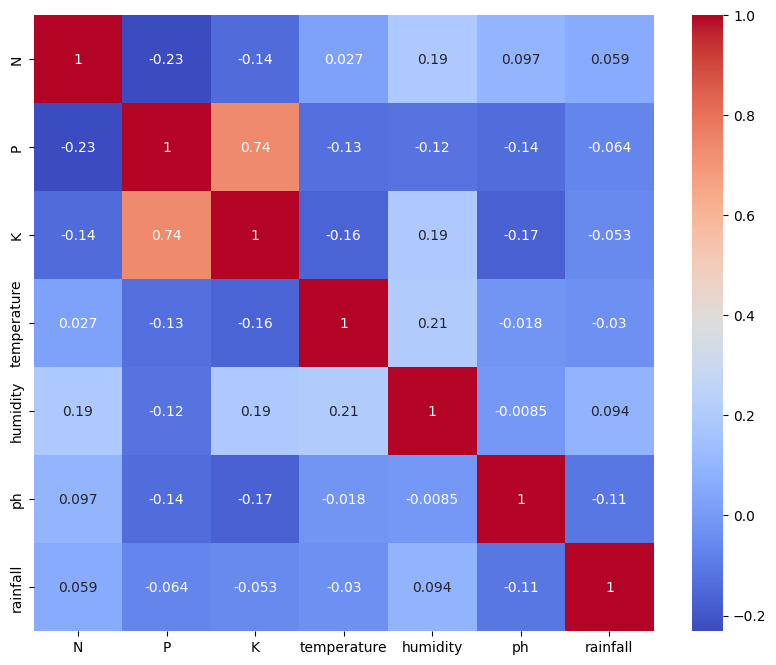

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(crop.drop("label",axis=1).corr(),
            annot=True,
            cmap="coolwarm"
)
plt.show()

In [9]:
crop.skew(numeric_only=True)

N              0.509721
P              1.010773
K              2.375167
temperature    0.184933
humidity      -1.091708
ph             0.283929
rainfall       0.965756
dtype: float64

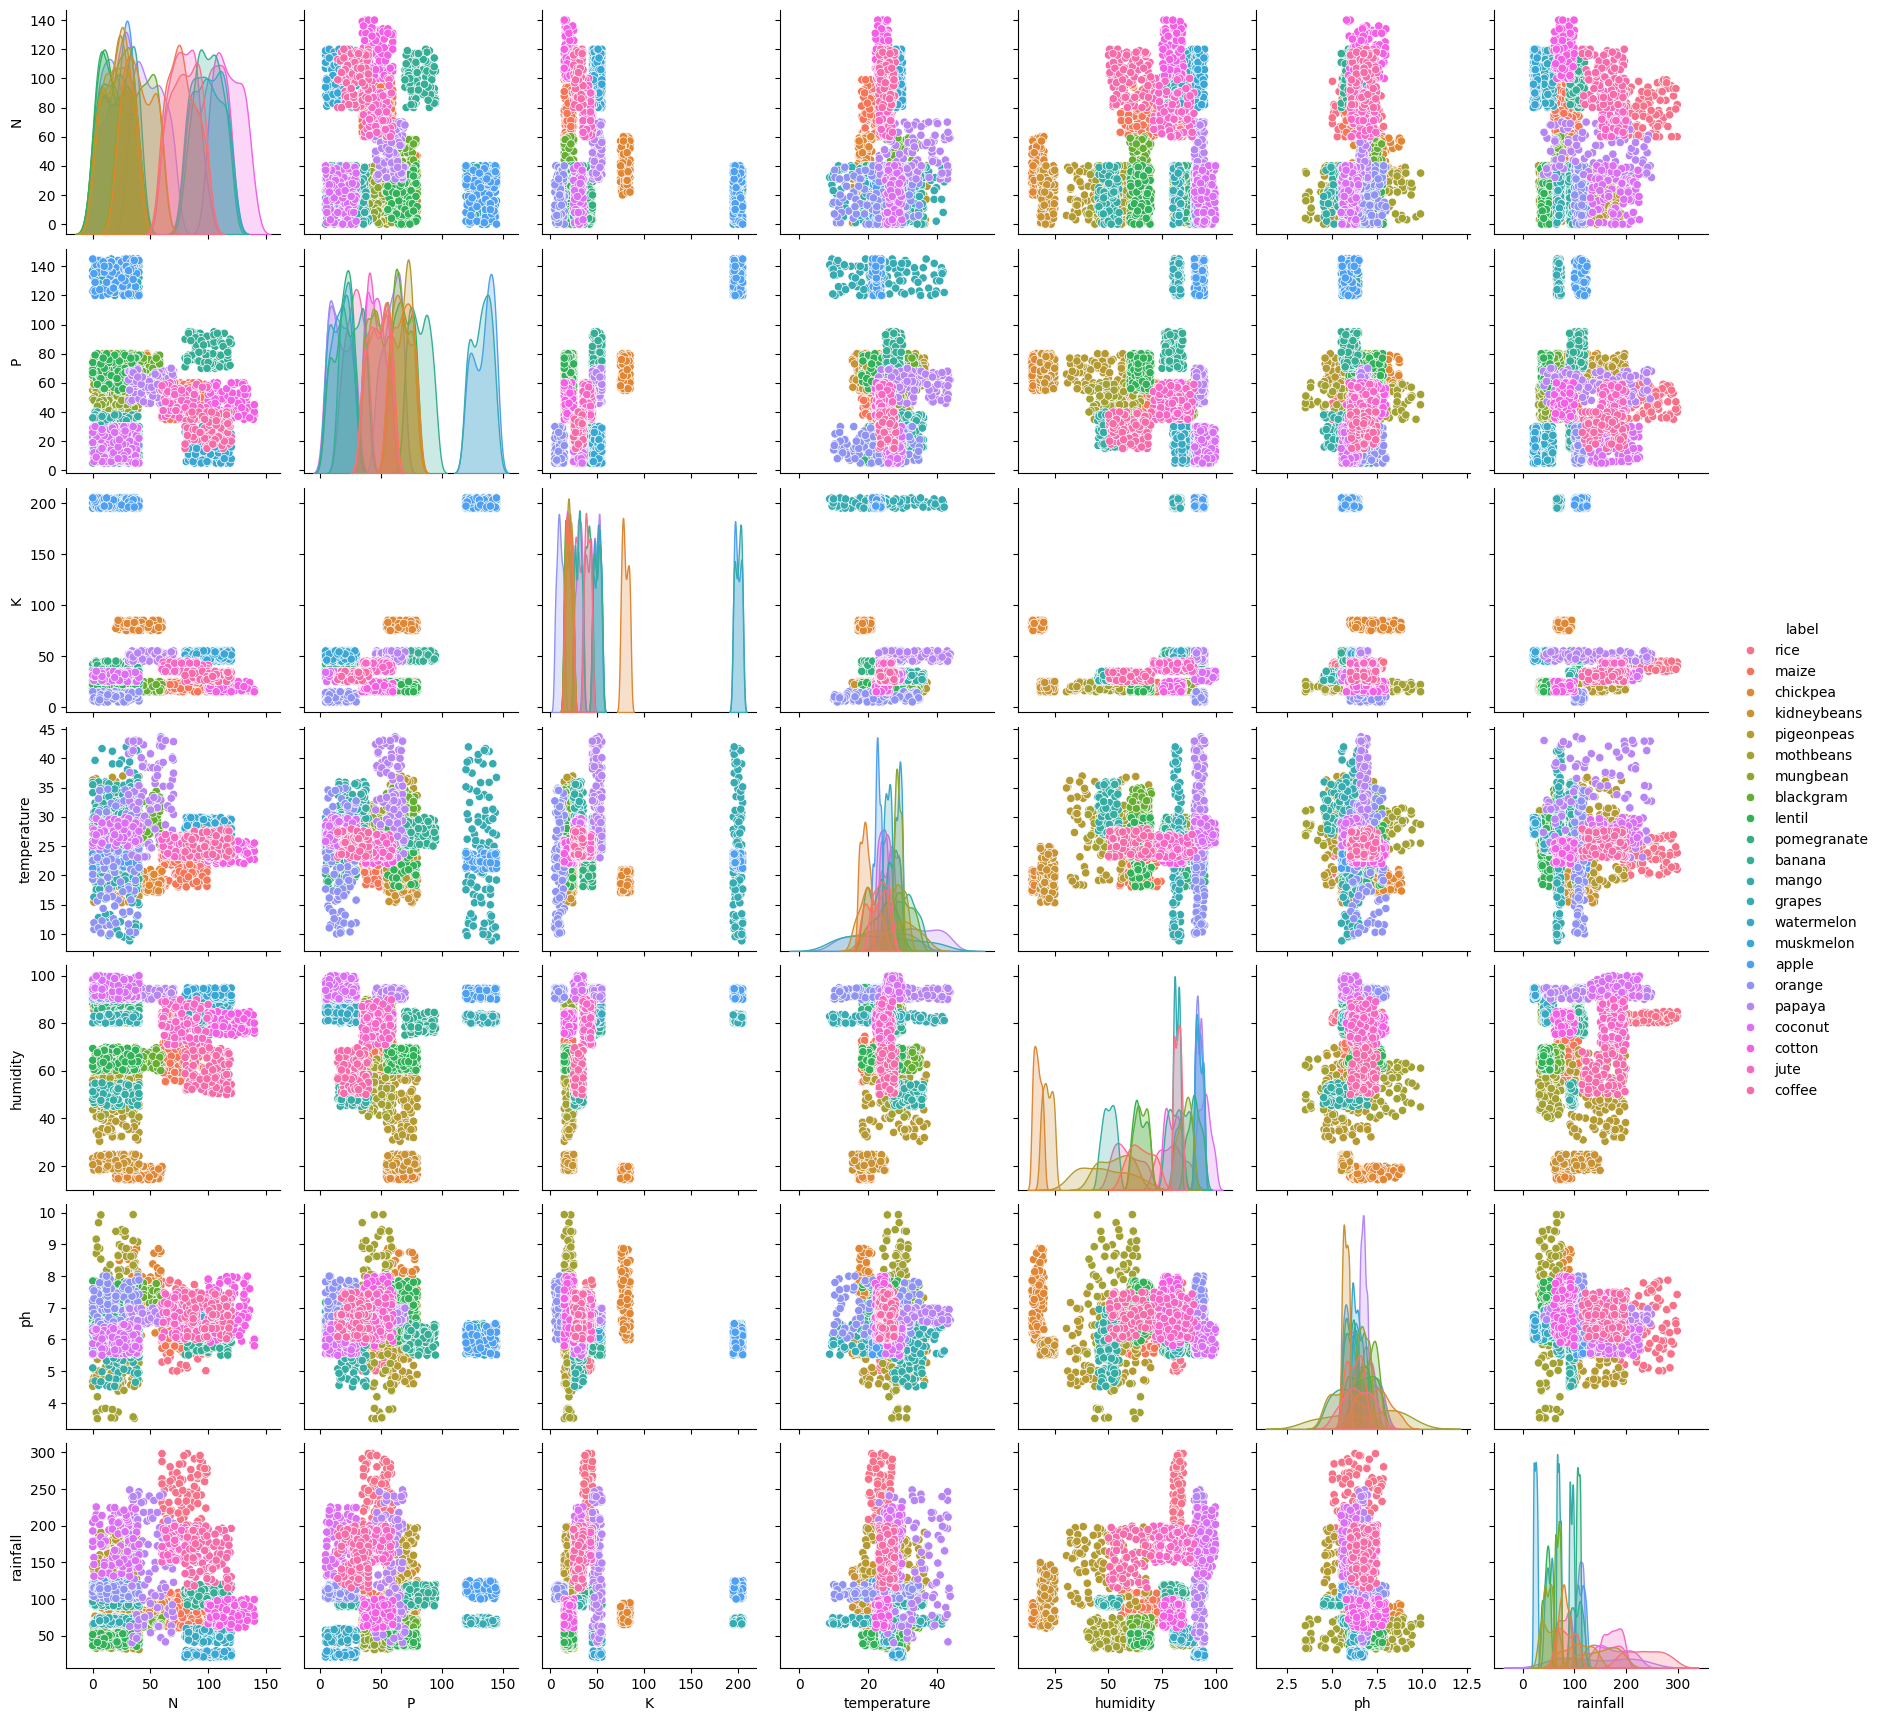

In [30]:
sns.pairplot(crop,hue="label")
plt.show()

### Encoding and Scaling

In [39]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
import pickle

encoder = LabelEncoder()
scaler = StandardScaler()

crop['label'] = encoder.fit_transform(crop['label'])


pickle.dump(encoder,open("../model/label_encoder.pkl","wb"))

### Feature Selection

In [20]:
X = crop.drop('label',axis=1)
Y = crop['label']

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


pickle.dump(scaler,open("../model/crop_scaler.pkl","wb"))


### Applying Various Algorithms and Comparing Results

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

### KNN

In [22]:
model_KNN = KNeighborsClassifier()
model_KNN.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [23]:
train_pred_KNN = model_KNN.predict(X_train)
test_pred_KNN = model_KNN.predict(X_test)

In [24]:
print("train accuracy KNN ",accuracy_score(y_train,train_pred_KNN))
print("test accuracy KNN ",accuracy_score(y_test,test_pred_KNN))

train accuracy KNN  0.9869318181818182
test accuracy KNN  0.9568181818181818


### Decision Tree

In [25]:
model_DT = DecisionTreeClassifier()
model_DT.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
train_pred_DT = model_DT.predict(X_train)
test_pred_DT = model_DT.predict(X_test)

In [27]:
print("train accuracy DT ",accuracy_score(y_train,train_pred_DT))
print("test accuracy DT ",accuracy_score(y_test,test_pred_DT))

train accuracy DT  1.0
test accuracy DT  0.9840909090909091


### Logistic Regression

In [28]:
model_LR = LogisticRegression()
model_LR.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
train_pred_LR = model_LR.predict(X_train)
test_pred_LR = model_LR.predict(X_test)

In [30]:
print("train accuracy LR ",accuracy_score(y_train,train_pred_LR))
print("test accuracy LR ",accuracy_score(y_test,test_pred_LR))

train accuracy LR  0.977840909090909
test accuracy LR  0.9636363636363636


### Random Forest 

In [31]:
model_RF = RandomForestClassifier(n_estimators=100)
model_RF.fit(X_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
train_pred_RF = model_RF.predict(X_train)
test_pred_RF = model_RF.predict(X_test)

In [33]:
print("train accuracy RF ",accuracy_score(y_train,train_pred_RF))
print("test accuracy RF ",accuracy_score(y_test,test_pred_RF))

train accuracy RF  1.0
test accuracy RF  0.9931818181818182


In [37]:
print(classification_report(y_test, test_pred_RF))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

In [ ]:
model = model_RF
pickle.dump(model,open("../model/crop_model.pkl","wb"))